In [3]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Makes charts look clean and professional
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print(' Dataset loaded ')

 Dataset loaded 


In [4]:
# LOADING THE DATASET
# ONLINE RETAIL DATASET


# ENCODING - ISO-8859-1 ( IT SUPPORTS ALL CHARACTERS, ENGLISH, WESTERN EUROPEAN SYMBOLS ETC)
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')

print(f' Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns')

 Dataset loaded: 541,909 rows and 8 columns


In [5]:
# UNDERSTANDING THE DATASET

print("=====DATASET INFO=====")
print(df.info())

print("=====DATASET DESCRIPTION=====")
print(df.describe())

print("=====MISSING VALUES=====")
print(df.isnull().sum())

print("=====DUPLICATE VALUES=====")
print(df.duplicated().sum())

print("=====DATASET HEAD=====")
print(df.head())

print("=====DATASET TAIL=====")
print(df.tail())




=====DATASET INFO=====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
=====DATASET DESCRIPTION=====
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.0800

In [6]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
# DATA CLEANING

# REMOVING ROWS WITH MISSING CUSTOMER ID
df = df.dropna(subset=['CustomerID'])

# REMOVING CANCELLED ORDERS (INVOICE NO STARTS WITH 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# REMOVING INVALID QUANTITY AND UNIT PRICE
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# CONVERTING INVOICE DATE TO DATETIME
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])



# EXTRACTING USEFUL TIME COLUMNS
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Year'] = df['InvoiceDate'].dt.year
df['MonthName'] = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()


# CREATING A REVENUE COLUMN
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print(f'Total Revenue in dataset: £{df["Revenue"].sum():,.2f}')


Total Revenue in dataset: £8,911,407.90


### KPI SUMMARY - KEY BUSINESS METRICS

In [8]:
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products   = df['Description'].nunique()
total_countries  = df['Country'].nunique()
avg_order_value  = total_revenue / total_orders


print(f'Total Revenue       : £{total_revenue:,.2f}')
print(f'Total Orders        : {total_orders:,}')
print(f'Unique Customers    : {total_customers,}')
print(f'Unique Products     : {total_products:,}')
print(f'Countries Served    : {total_countries:,}')
print(f'Avg Order Value     : £{avg_order_value:,.2f}')

Total Revenue       : £8,911,407.90
Total Orders        : 18,532
Unique Customers    : (4338,)
Unique Products     : 3,877
Countries Served    : 37
Avg Order Value     : £480.87


### REVENUE TREND OVER TIME

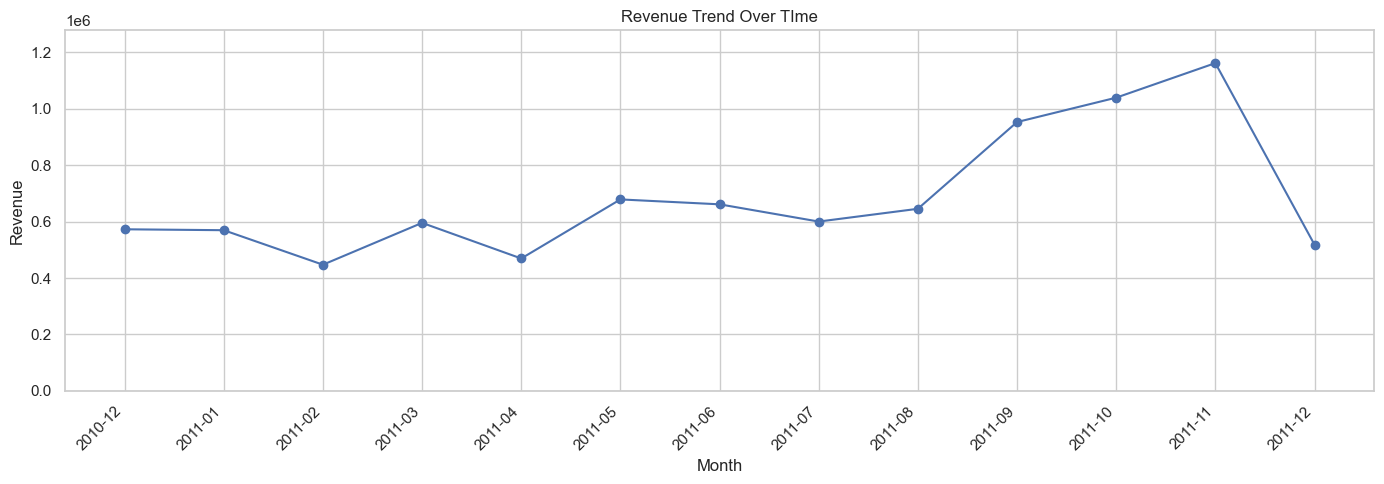

In [9]:
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month_str'] = monthly_revenue['Month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['Month_str'], monthly_revenue['Revenue'],
marker='o')

ax.set_title('Revenue Trend Over TIme')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.set_xticks(monthly_revenue['Month_str'])
ax.set_xticklabels(monthly_revenue['Month_str'], rotation=45, ha='right')
ax.set_ylim(0, monthly_revenue['Revenue'].max() * 1.1)

plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()



### TOP 10 BEST SELLING PRODUCTS

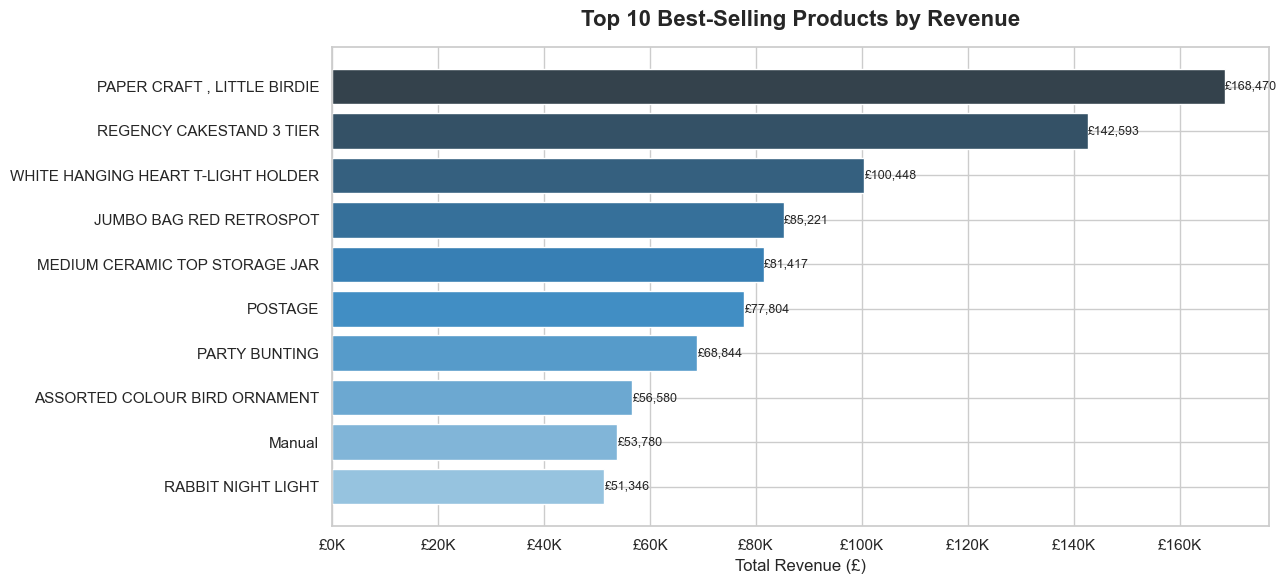

In [10]:
top_products = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_products['Description'][::-1],
               top_products['Revenue'][::-1],
               color=sns.color_palette('Blues_d', 10))


for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y()+ bar.get_height()/2,
            f'£{width:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Best-Selling Products by Revenue', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('chart_02_top_products.png', dpi=150, bbox_inches='tight')
plt.show()


### TOP 10 HIGH VALUE CUSTOMERS

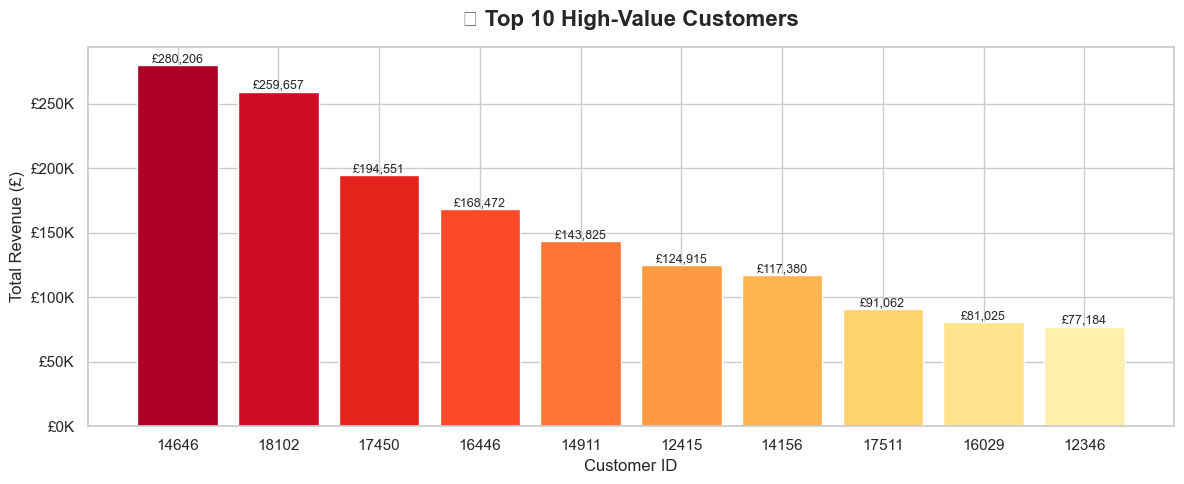

In [11]:
top_customers = (df.groupby('CustomerID')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())
top_customers['CustomerID'] = top_customers['CustomerID'].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_customers['CustomerID'], top_customers['Revenue'],
              color=sns.color_palette('YlOrRd', 10)[::-1])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 100,
            f'£{height:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('👑 Top 10 High-Value Customers', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Customer ID', fontsize=12)
ax.set_ylabel('Total Revenue (£)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('chart_03_top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

### REVENUE BY COUNTRY ( TOP 10 )

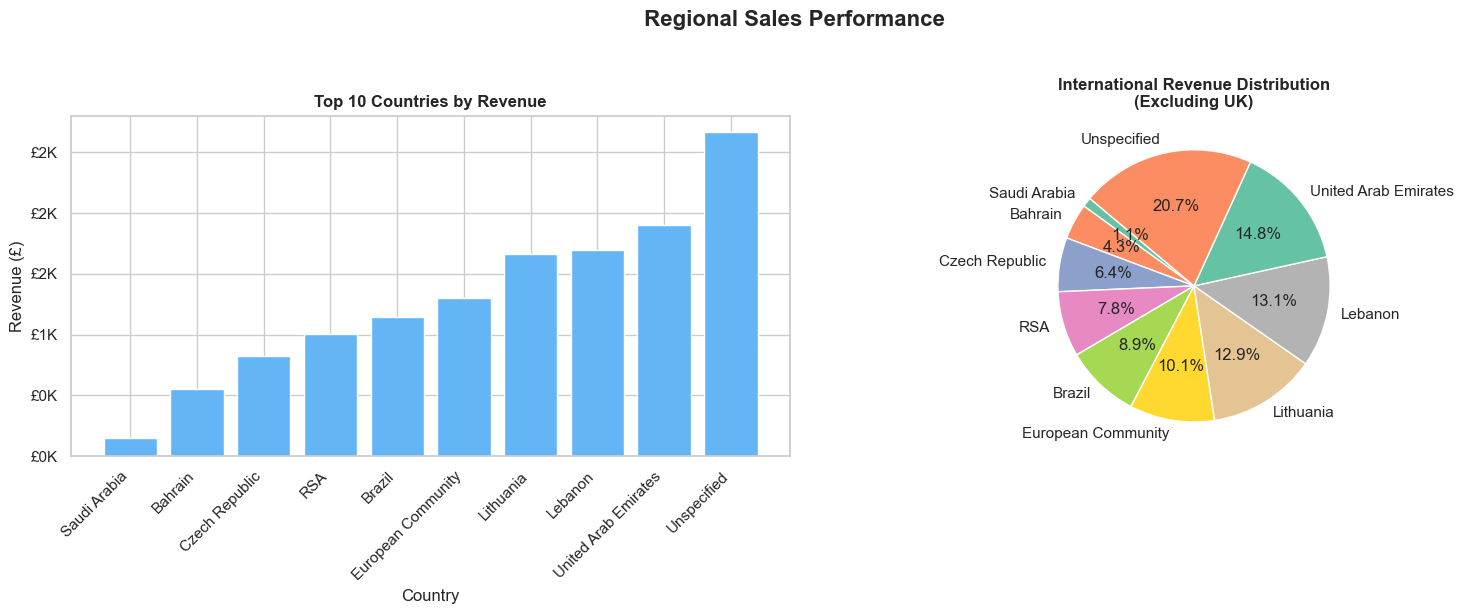

In [21]:
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values()
    .head(10)
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))


colors = ['#FF5722' if c == 'United Kingdom' else '#64B5F6' for c in country_revenue['Country']]


# Bar chart — All top 10
colors = ['#FF5722' if c == 'United Kingdom' else '#64B5F6' for c in country_revenue['Country']]
ax1.bar(country_revenue['Country'], country_revenue['Revenue'], color=colors)
ax1.set_title('Top 10 Countries by Revenue', fontweight='bold')
ax1.set_xlabel('Country')
ax1.set_ylabel('Revenue (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Pie chart — Excluding UK to see international breakdown
intl = country_revenue[country_revenue['Country'] != 'United Kingdom']
ax2.pie(intl['Revenue'], labels=intl['Country'], autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(intl)), startangle=140)
ax2.set_title('International Revenue Distribution\n(Excluding UK)', fontweight='bold')

plt.suptitle(' Regional Sales Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_04_country_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### TOP 10 PRODUCTS BY QUANTITY SOLD

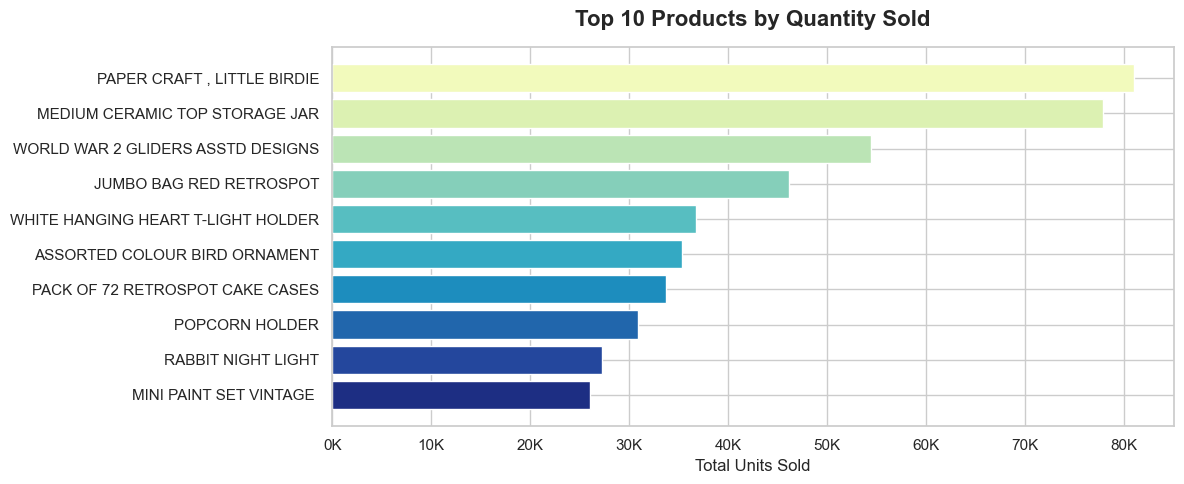

In [13]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_products['Description'][::-1], top_products['Quantity'][::-1],
        color=sns.color_palette('YlGnBu', 10)[::-1])
            
ax.set_title('Top 10 Products by Quantity Sold', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Units Sold', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('chart_05_top_qty_products.png', dpi=150, bbox_inches='tight')
plt.show()

### SALES BY DAY OF WEEK

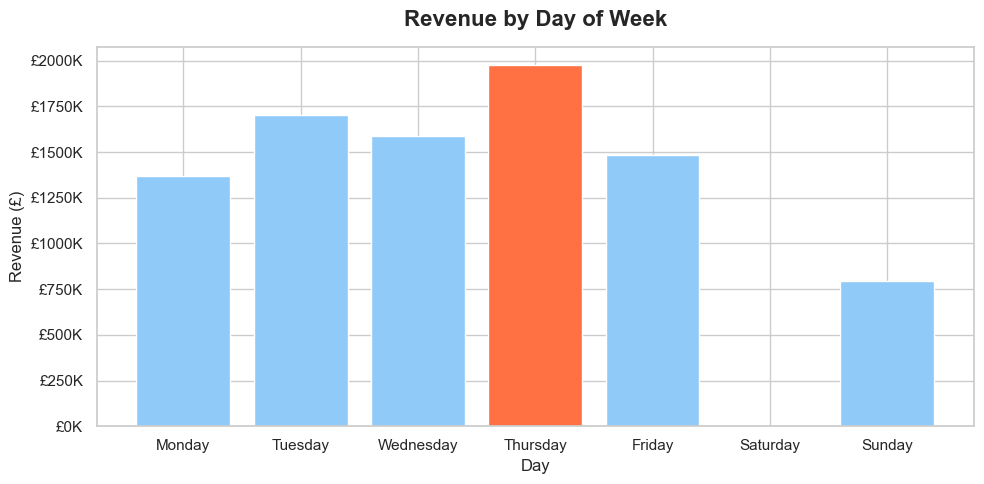

In [14]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue = (df.groupby('DayOfWeek')['Revenue']
               .sum()
               .reindex(day_order)
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#FF7043' if r == day_revenue['Revenue'].max() else '#90CAF9'
              for r in day_revenue['Revenue']]
ax.bar(day_revenue['DayOfWeek'], day_revenue['Revenue'], color=bar_colors)
ax.set_title('Revenue by Day of Week', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Revenue (£)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('chart_06_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

### REPEAT VS ONE-TIME CUSTOMERS

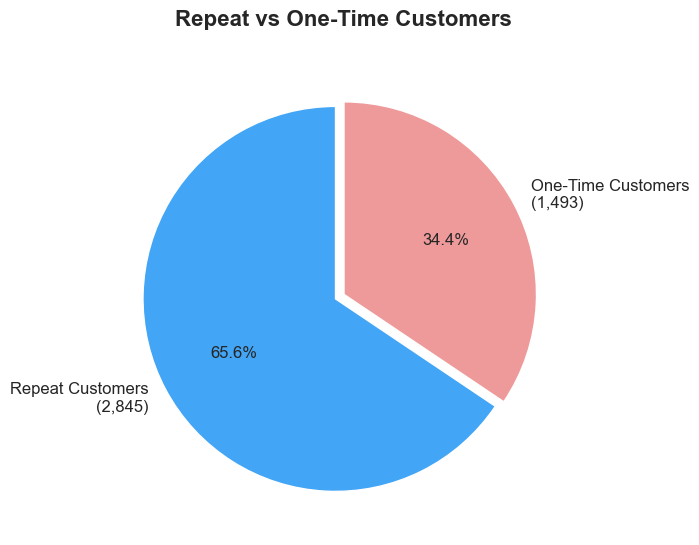

In [20]:
purchase_counts = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat = (purchase_counts > 1).sum()
one_time = (purchase_counts == 1).sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([repeat, one_time],
       labels=[f'Repeat Customers\n({repeat:,})', f'One-Time Customers\n({one_time:,})'],
       autopct='%1.1f%%',
       colors=['#42A5F5', '#EF9A9A'],
       startangle=90,
       explode=(0.05, 0),
       textprops={'fontsize': 12})
ax.set_title('Repeat vs One-Time Customers', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart_07_repeat_customers.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Insight And Recommendations

In [19]:
best_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax(), 'Month_str']
best_country = country_revenue.iloc[0]['Country']
best_product = top_products.iloc[0]['Description']
best_customer = top_customers.iloc[0]['CustomerID']
best_day = day_revenue.loc[day_revenue['Revenue'].idxmax(), 'DayOfWeek']
repeat_pct = round(repeat / (repeat + one_time) * 100, 1)

print('=' * 55)
print(' KEY INSIGHTS & RECOMMENDATIONS')
print('=' * 55)

print(f"""
 INSIGHT 1 — Revenue Peak:
   Highest revenue month is {best_month}.
   → Consider running targeted promotions in the months
     leading up to this peak to maximize revenue.

 INSIGHT 2 — Top Market:
   {best_country} dominates revenue.
   → Invest in customer retention in this market.
   → Explore what's working here and replicate
     it in other countries.

 INSIGHT 3 — Star Product:
   '{best_product}' is the top revenue-generating product.
   → Ensure consistent stock availability.
   → Use it as an anchor in bundle deals.

 INSIGHT 4 — VIP Customer:
   Customer {best_customer} has the highest lifetime spend.
   → Implement a VIP loyalty program for top customers.
   → Assign dedicated account managers to top 10 customers.

 INSIGHT 5 — Best Day:
   {best_day} generates the most revenue.
   → Schedule flash sales and email campaigns on this day.

 INSIGHT 6 — Customer Loyalty:
   {repeat_pct}% of customers are repeat buyers.
   → Focus on converting one-time buyers through
     post-purchase email sequences and loyalty rewards.
""")
print('=' * 55)

 KEY INSIGHTS & RECOMMENDATIONS

 INSIGHT 1 — Revenue Peak:
   Highest revenue month is 2011-11.
   → Consider running targeted promotions in the months
     leading up to this peak to maximize revenue.

 INSIGHT 2 — Top Market:
   Saudi Arabia dominates revenue.
   → Invest in customer retention in this market.
   → Explore what's working here and replicate
     it in other countries.

 INSIGHT 3 — Star Product:
   'PAPER CRAFT , LITTLE BIRDIE' is the top revenue-generating product.
   → Ensure consistent stock availability.
   → Use it as an anchor in bundle deals.

 INSIGHT 4 — VIP Customer:
   Customer 14646 has the highest lifetime spend.
   → Implement a VIP loyalty program for top customers.
   → Assign dedicated account managers to top 10 customers.

 INSIGHT 5 — Best Day:
   Thursday generates the most revenue.
   → Schedule flash sales and email campaigns on this day.

 INSIGHT 6 — Customer Loyalty:
   65.6% of customers are repeat buyers.
   → Focus on converting one-time bu

### EXPORT SUMMARY TO CSV

In [17]:
# Save monthly revenue
monthly_revenue.to_csv('summary_monthly_revenue.csv', index=False)

# Save top products
top_products.to_csv('summary_top_products.csv', index=False)

# Save country revenue
country_revenue.to_csv('summary_country_revenue.csv', index=False)

# Save top customers
top_customers.to_csv('summary_top_customers.csv', index=False)

# Save cleaned full dataset
df.to_csv('online_retail_cleaned.csv', index=False)


print(' --> Import online_retail_cleaned.csv into Power BI for dashboard creation.')

 --> Import online_retail_cleaned.csv into Power BI for dashboard creation.
